In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from ariel_pred.dataset import DataLoaderAndCalibrator
from ariel_pred.preprocessing import SGSmoothing
from ariel_pred.plots import plot_white_curve
from ariel_pred.transit import FunctionFittingBasedPhaseDetector
from ariel_pred.models import TransitMultiplicationFactorFinder, SValuesCNN, SValuesCNNTrainer
from ariel_pred.features import WavelengthsGroupsMultiplierFinder, PerChannelFluctuationsFinder
from ariel_pred.metrics import score, gll
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random
from scipy.optimize import minimize
from tqdm.auto import tqdm
import pandas as pd
import torch
from torch import nn
import scipy

In [3]:
data_loader = DataLoaderAndCalibrator(
    data_path=Path("../data/raw"),
    output_path=Path("../data/calibrated/full"),
    force_recalibration=False,
    cut_airs_channels=True,
    binning=4,
    n_jobs=4
)
train_data, train_labels = data_loader.load_all_train_data()
train_data.shape, train_labels.shape

Loading calibrated train data...


((1100, 1406, 283), (1100, 283))

In [5]:
features_extractor = WavelengthsGroupsMultiplierFinder()

features, transit_locations = features_extractor.extract_features(
    train_data,
    average_cross_groups=False,
    wavelengths_groups=[1, 2, 4, 8, 16, 32, 64],
    weights=[1, 1, 1, 1, 1, 1, 1],
    return_transit_locations=True
)

features.shape

100%|██████████| 1100/1100 [03:23<00:00,  5.42it/s]


(1100, 283, 7)

In [6]:
per_channel_fluctuations_extractor = PerChannelFluctuationsFinder()
per_channel_fluctuations = per_channel_fluctuations_extractor.extract_features(
    train_data,
    transit_locations=transit_locations
)
per_channel_fluctuations.shape

  0%|          | 0/1100 [00:00<?, ?it/s]

(1100, 283)

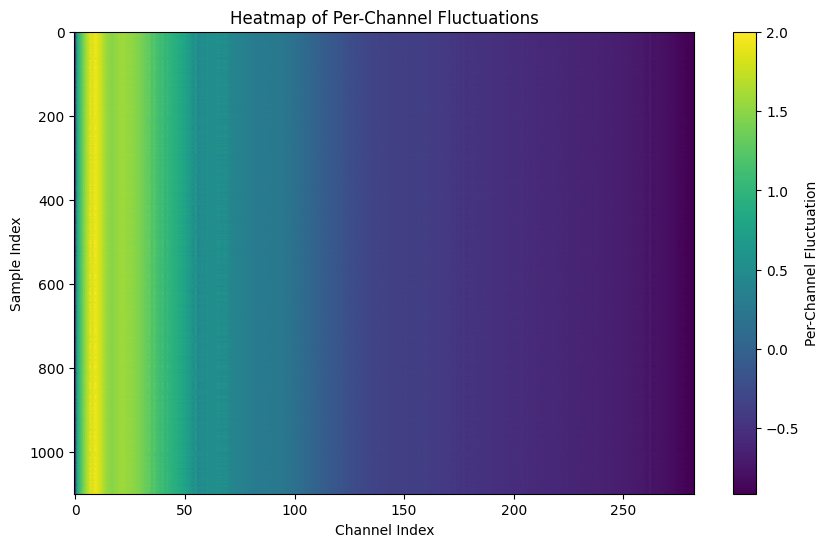

In [9]:
# Heatmap of per-channel fluctuations. Shape: (num_samples, num_channels)

plt.figure(figsize=(10, 6))
plt.imshow(per_channel_fluctuations, aspect='auto', cmap='viridis')
plt.colorbar(label='Per-Channel Fluctuation')
plt.xlabel('Channel Index')
plt.ylabel('Sample Index')
plt.title('Heatmap of Per-Channel Fluctuations')
plt.show()

In [12]:
per_channel_fluctuations

array([[-0.55304036,  0.83775259,  1.0494529 , ..., -0.89923314,
        -0.90170346, -0.90843602],
       [-0.34997785,  0.84284479,  1.05742477, ..., -0.90058655,
        -0.90290019, -0.9097395 ],
       [-0.72363789,  0.82782904,  1.03094324, ..., -0.89728567,
        -0.89965744, -0.90633301],
       ...,
       [-0.3236305 ,  0.84935282,  1.06465419, ..., -0.89236679,
        -0.9018346 , -0.90956109],
       [-0.70233049,  0.82769036,  1.03272416, ..., -0.89749346,
        -0.89988894, -0.90674799],
       [-0.53038207,  0.84192494,  1.05448869, ..., -0.89098406,
        -0.9005943 , -0.90839663]], shape=(1100, 283))

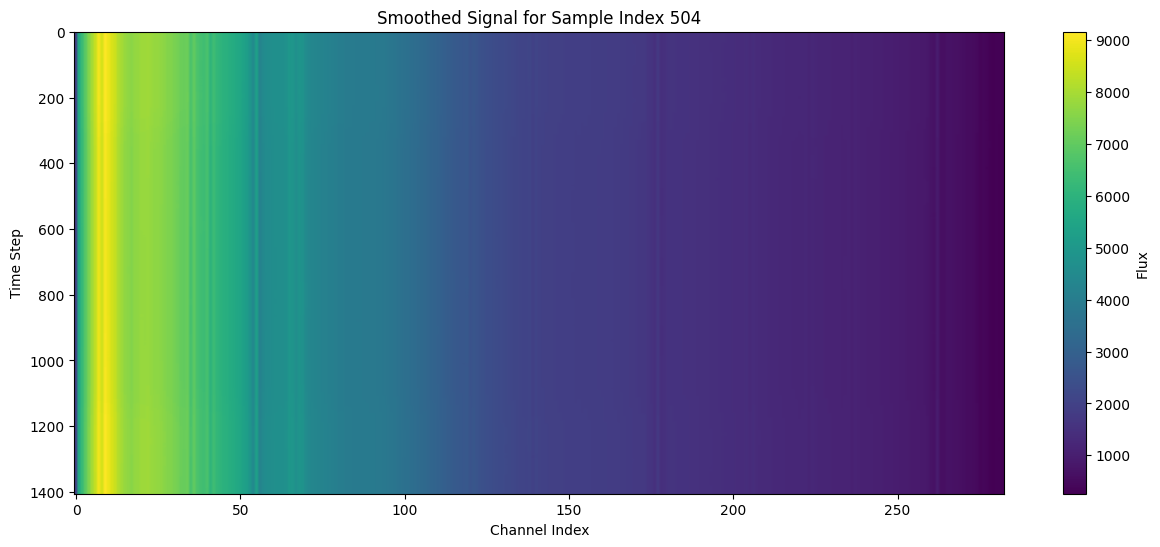

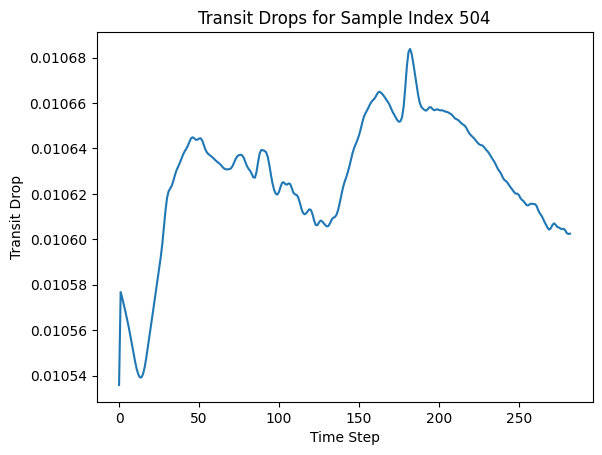

In [104]:
random_index = random.randint(0, train_data.shape[0] - 1)
smoother = SGSmoothing(window_size=150, poly_order=3)
# signal = smoother.smooth(train_data[random_index]) # Shape is (time_steps, num_channels)
signal = np.array([smoother.smooth(train_data[random_index, :, i]) for i in range(train_data.shape[2])]).T
plt.figure(figsize=(15, 6))
plt.imshow(signal, aspect='auto', cmap='viridis')
plt.colorbar(label='Flux')
plt.xlabel('Channel Index')
plt.ylabel('Time Step')
plt.title(f'Smoothed Signal for Sample Index {random_index}')
plt.show()
plt.plot(train_labels[random_index])
plt.title(f'Transit Drops for Sample Index {random_index}')
plt.xlabel('Time Step')
plt.ylabel('Transit Drop')
plt.show()

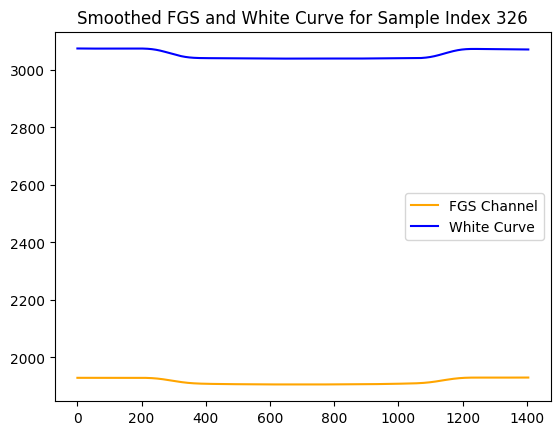

In [138]:
random_index = random.randint(0, train_data.shape[0] - 1)
plt.plot(smoother.smooth(signal[:, 0]), label='FGS Channel', color='orange')
plt.plot(smoother.smooth(signal[:, 1:].mean(axis=1)), label='White Curve', color='blue')
plt.title(f'Smoothed FGS and White Curve for Sample Index {random_index}')
plt.legend()
plt.show()

In [143]:
train_labels.mean(axis=0)[0], train_labels.mean(axis=0)[1:].mean(), train_labels.mean(axis=0)[1:].std()

(np.float64(0.014609346767622418),
 np.float64(0.014689302060069223),
 np.float64(8.70383483579067e-05))